<br><br>

## 🟢 이진분류 평가지수  

체인지전
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
체인지후
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
{np.int64(0): np.int64(357), np.int64(1): np.int64(212)}
오차행렬
[[86  2]
 [ 3 52]]
              precision    recall  f1-score   support

          양성       0.97      0.98      0.97        88
          악성       0.96      0.95      0.95        55

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



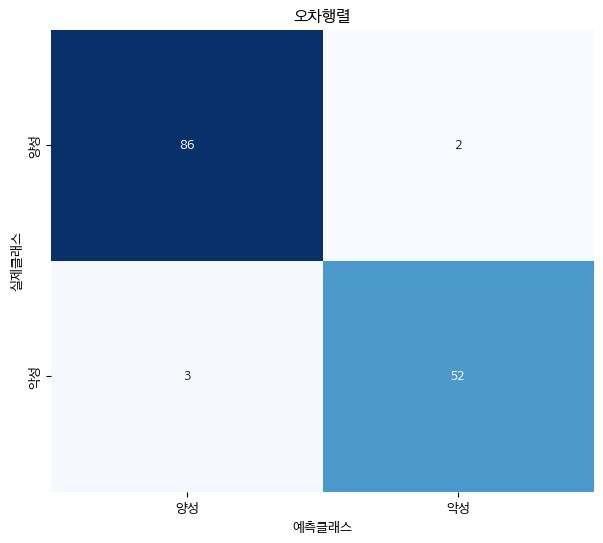

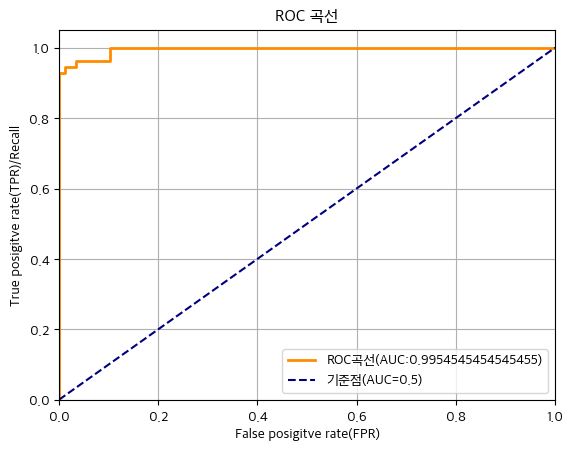

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer # 유방암 데이터셋
from sklearn.preprocessing import StandardScaler # 데이터 스케일링

import matplotlib.pyplot as plt
import seaborn as sns # Seaborn 라이브러리 임포트

plt.rcParams['font.family'] = 'Apple SD Gothic Neo' # 설치된 나눔고딕 폰트 이름으로 변경
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

cancer = load_breast_cancer() 
X = pd.DataFrame(cancer.data, columns= cancer.feature_names)
y = cancer.target #0:악성, 1:음성 
#평가할때 양성기준 - 필요해서 붙인거  악성-> 양성(1)로 보는 판단하기 편하다. 악성, 음성을 서로 바꾸자 
y_changed = np.where(y==0, 1, 0)    #numpy에 where 조건식을 만족하면 (조건식, 값1, 값2)
                                    #조건식을 만족하면 값1, 만족하지 않으면 값2를 반환 
print("체인지전")
print(y[:20])
print("체인지후")
print(y_changed[:20])

#데이터가 불균형셋인지 확인해보자 
print( dict(zip(*np.unique(y_changed, return_counts=True))))

#데이터 쪼개기 
X_train, X_test, y_train, y_test = train_test_split(X, y_changed, random_state=1)

#특성스케일링 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

#학습
model = LogisticRegression(random_state=1, solver='liblinear')
model.fit(X_train_scaled, y_train)

#예측값 가져오기 
y_pred = model.predict(X_test_scaled)
#양성예측한것만 가져오기, 악성에 대한 예측 확률 하나만 가져오기  
y_pred_proba = model.predict_proba(X_test_scaled)[:,1] 

#오차행렬 구하기 
cm = confusion_matrix(y_test, y_pred)
print("오차행렬")
print(cm)

#분류리포트 
report = classification_report(y_test, y_pred, target_names=['양성', '악성'])
print(report)

#seaborn 차트를 이용한 시각화 
plt.figure( figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['양성', '악성'],
            yticklabels=['양성', '악성'] )
plt.xlabel('예측클래스')
plt.ylabel('실제클래스')
plt.title('오차행렬')
plt.show() 

#ROC곡선  roc_curve 함수가 3개의 반환값을 준다 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC곡선(AUC:{auc_score})')
plt.plot([0,1], [0,1], color='navy', linestyle='--', label='기준점(AUC=0.5)')
plt.xlim([0.0, 1.0]) #눈금 범위 
plt.ylim([0.0, 1.05]) #눈금범위 
plt.xlabel('False posigitve rate(FPR)')
plt.ylabel('True posigitve rate(TPR)/Recall')
plt.title("ROC 곡선")
plt.legend(loc="lower right") #범주는 오른쪽 하단에
plt.grid(True) #격자선 그리기 
plt.show()

#roc곡선 아래의 영역을 auc 라고 부르고, 1에 가까울 수록 좋다  
